In [1]:
from PIL import Image
import matplotlib.pyplot as plt

# 🧠 Nextify — Your Innovation Co-Pilot

Nextify is your end-to-end innovation assistant, designed to take you from that first spark of an idea all the way to a validated MVP execution plan.
If you’ve ever wondered:

“I have an idea… what do I do next?”
Nextify becomes your co-pilot.

It guides you through each stage of the product innovation lifecycle using an orchestrated set of specialized AI agents—each responsible for a different phase of the journey.
From brainstorming → roadmap → features → prioritization → OKRs → planning, Nextify ensures clarity, structure, and rigor, while keeping you in the driver’s seat through built-in user review loops.

**🧩 Multi-Agent Architecture Overview**

Below is the full agentic workflow used inside Nextify.
This diagram shows how each agent contributes to the overall process—from idea intake to a finalized MVP plan.


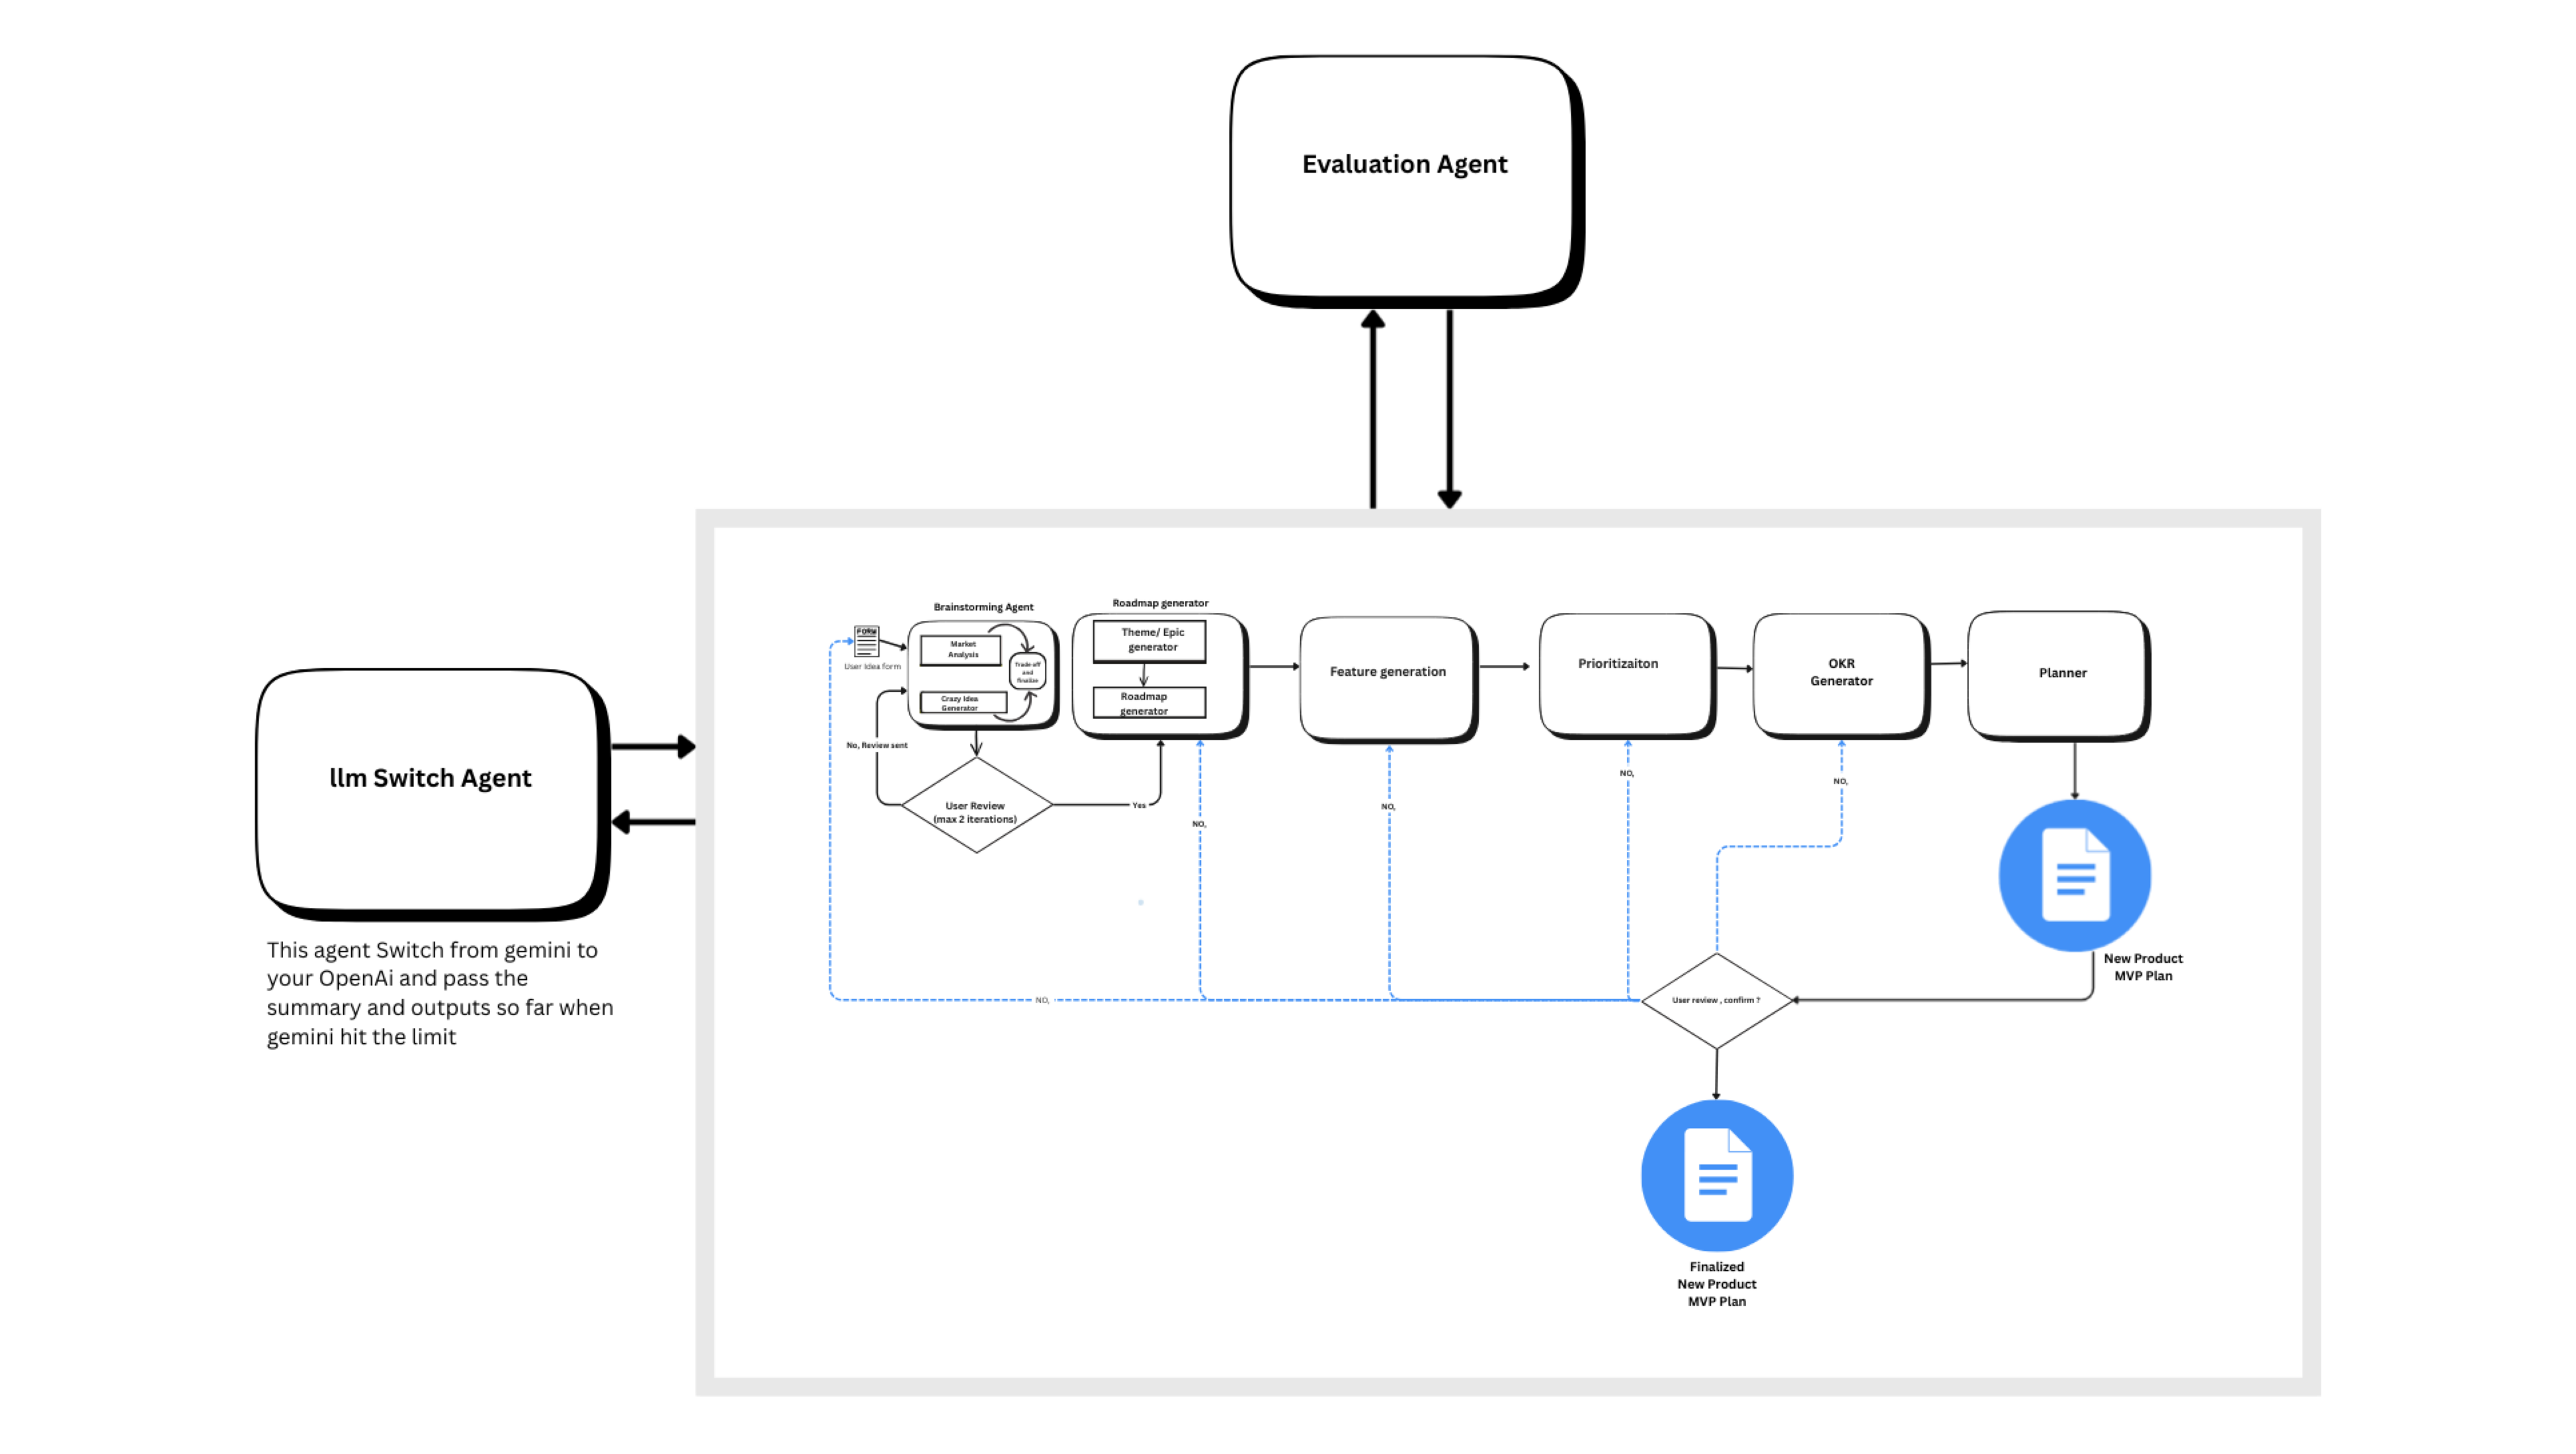

In [2]:
img = Image.open('/kaggle/input/nextify-multi-agent-architecture/Nextify Multiagent Architecture.png')
plt.figure(figsize=(50, 30))
plt.imshow(img)
plt.axis('off');

🌟 **Meet the Nextify Agents — Your Innovation Crew**

Welcome aboard the Nextify Innovation Airline, where every agent is a crew member helping your raw idea take off and land as a fully-baked MVP.
Here’s how each one works — and how they pass the baton to each other to transform your idea into a structured 3-month product plan.
Before jumping into explaining the agents and subagents let's start with two agents that are used by other agents per request during the whole user journey:

**🔄 1. LLM Switch Agent**

- *Personality*: The multilingual airline dispatcher who reroutes flights when airspace gets congested.
- *Role*: Automatically switches from Gemini → OpenAI when you hit the free token limit — but only after asking for your confirmation.

- *How It Works*

    It monitors usage, cost, or token availability.

    When Gemini hits its limit, it politely asks you:
    “Shall I switch to OpenAI to continue?”

    If you say Yes:

    It summarizes everything generated so far

    Collects:

        - brainstormed ideas

        - product snapshot

        - themes & epics

        - roadmap

        - features

        - RICE scores

        - OKRs

        - draft planning structure

    Packs this into a compact LLM memory object

    Hands it over to OpenAI as context to continue the remaining pipeline

    If you say No, it pauses until you upgrade, refresh, or manually restart.

- *Why It’s Useful*

    You never lose progress

    You never re-run earlier steps

    It behaves like a built-in session-transfer memory system

    It makes your workflow resilient even if one model stops responding

    Think of it as the plug-and-play brain transplant surgeon:
        When one model gets tired, it moves the idea-brain into the next one            and says,
    “Fresh brain installed. Continue building!”

**🧪 2. Evaluation Agent**

- *Personality*: The strict-but-fair reviewer who checks everyone’s homework.
- *Role*: Evaluates outputs from each agent and provides quality scoring,     sanity checks, and improvement suggestions.

- *When It Runs*

    The Evaluation Agent is triggered after every major agent output, including:

        - Brainstorming outputs

        - Product snapshot

        - Themes & epics

        - Roadmap

        - Features

        - RICE scores

        - OKRs

        - Planning breakdown

    It acts as a post-processing auditor, offering comments such as:

        “This feature does not match any epic.”

        “These OKRs are not measurable.”

        “The roadmap is too ambitious for the constraints.”

        “This theme does not match the user problem.”

        “RICE confidence is too low — consider revisiting.”

- *What It Produces*

    - A short evaluation report

    - Scores (clarity, feasibility, alignment, completeness)

    - Suggestions to improve

    - Flags to warn downstream agents

- *Why It’s Useful*

    Without an evaluation layer, multi-agent systems can drift.
    This agent ensures the system outputs remain:

        - consistent

        - realistic

        - aligned with the user idea

        - Connected from stage to stage

It’s your internal quality assurance department, run by the LLM itself.
Now let's go into the agents one by one:
**🌱 Input: Founder • Start with your Idea Form**

This form is the single source of truth that kicks everything off.
Nextify reads these fields:

**Idea title** – the working name of your baby 🌟

**Current stage** – idea / prototype / MVP / scaling

**Region** – e.g. Global, EU, US-East (used for market context)

**What problem does it solve?** – your core problem statement

**Who is it for?** – target users / segments

**Constraints (optional)** – budget, time, tech, team, or “please no blockchain”

All of this is packed into a structured founder_idea object and handed to the agents.

**🧠 1. Brainstorming Agent**

Personality: The creative strategy squad.
Input: All fields from the idea form.
Output: 2–3 refined, market-aware concept options.

Inside it, three sub-agents work together:

*💡 1.1 Crazy Idea Generator*

Cranks the temperature up and explores wild variations of your idea.

Uses: idea title, problem, audience, constraints

Goal: “What’s the most exciting version of this idea if we aren’t afraid of being weird?”

*📊 1.2 Market Analysis*

Looks at the world outside your head: competitors, patterns, TAM/SAM/SOM, obvious gaps.

Uses: problem, audience, region, current stage

Goal: “How crowded is this space and where could you create the most value?”

**⚖️ 1.3 Tradeoff & Finalizer**

Takes the crazy concepts + market reality and blends them into 2–3 solid directions.

For each direction it explains:

- What it is

- Why it’s interesting

- Risks & tradeoffs

- How well it fits your constraints

These options are then sent to User Review.

**👀 2. User Review (max 2 iterations)**

- *Personality*: You as the Head of Product.

You see the candidate concepts and can:

    pick your favorite, 
    or
    say “No, tweak it” and give feedback (e.g. “more B2B”, “cheaper to build”,       “focus on EU market”).

If you say No, feedback goes back into the Brainstorming Agent and it runs another round.
This loop can happen up to 2 times — then Nextify picks the best match.

Once you’re happy, the chosen concept becomes the Product Snapshot.

**📌 3. Product Snapshot (artifact, not an agent)**

From the final brainstormed concept, Nextify crafts a structured snapshot:

- Clear problem & solution

- Who it’s for (from the form, plus refinements)

- Value proposition & differentiation

- Region / market context

- Key assumptions & constraints

This is the “single slide” that tells any PM or investor what you’re building.

**🗺️ 4. Roadmap Generator**

-*Personality*: The architect.
- *Input*: Product Snapshot (+ stage, region, constraints).
- *Output*: A high-level product roadmap.

It has two internal pieces:

**🧱 4.1 Theme / Epic Generator (sub-agent)**

Breaks the idea into themes (pillars) and epics (big chunks of work).

*Example themes: Onboarding, Core Experience, Analytics, Growth.*

*Uses: problem, audience, constraints, current stage*

Ensures we don’t plan tasks randomly — everything rolls up into a clear structure.

**🕒 4.2 Roadmap Generator (sub-agent)**

Places epics on a timeline (e.g. next 3–6 months).

Adds phases & milestones that make sense for your current stage and constraints.

Example:

    *Month 1–2: MVP*

    *Month 3–4: Beta & analytics*

    *Month 5–6: Growth features*

This produces the Strategic Roadmap passed into feature generation.

**🧩 5. Feature Generation Agent**

- *Personality: The builder.*
-*Input: Themes, epics, roadmap milestones.*
-*Output: A list of potential product features.*

For each epic it generates features with:

- Name

- Short description

- What user problem it solves

- Which theme/epic it belongs to rough sense of complexity or dependencies (guided by your constraints)

This is the “feature backlog” before prioritization.

**📊 6. Prioritization Agent (RICE)**

- *Personality*: The ruthless PM.
- *Input*: Generated features + any constraints from the form.
- *Output*: Features ranked by importance.

For each feature it estimates:

- *Reach* – how many users it affects

- *Impact* – how strongly it moves the needle

- *Confidence* – how sure we are about those guesses

- *Effort* – roughly how costly / hard it is

Then it calculates a RICE score and produces a prioritized feature list, highlighting the likely MVP slice.

**🎯 7. OKR Generator**

- *Personality*: The strategist.
- *Input*: Product Snapshot + Roadmap + prioritized features.
- *Output*: OKRs for the next quarter.

It generates:

- 3–5 Objectives (e.g. “Validate product-market fit with early adopters”)

- 2–4 Key Results per objective (e.g. “Onboard 50 active teams”, “NPS > 40”)

Each Key Result is linked to the features that can drive it, so you can always trace:
- feature → KR → Objective → original idea & problem.

**📆 8. Planner Agent (3-Month MVP Plan)**

- *Personality*: The project manager.
- *Input*: OKRs + prioritized feature list + constraints.
- *Output*: A realistic 3-month MVP plan.

It decides:

- Which features to ship in the next 3 months

- Which OKR each feature supports

- Rough order and phasing (Month 1 / 2 / 3)

- Any obvious resource/capacity implications (based on constraints you gave)

This becomes the “New Product MVP Plan” document.

**✅ 9. Final User Review & Confirmation**

At the end, you get the whole picture:

**Product Snapshot**

**Roadmap**

**Prioritized features**

**OKRs**

**3-month MVP plan**

This is exported as the “New Product MVP Plan.”

**🧪 Final Step — User Review & Confirmation**

- *Role*: Quality Control
At the end of the entire pipeline, you get a final decision diamond:

👉 Yes → Finalized MVP Plan Delivered
👉 No → You can jump back to any step in the workflow and re-run the part you want corrected.

This ensures infinite refinement at the final stage — your product, your rules.

In [5]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/agents-intensive-capstone-project/Hackathon dataset.txt
/kaggle/input/nextify-multi-agent-architecture/Nextify Multiagent Architecture.png


## ADK imports (matching the course notebooks)
These cells pull in the ADK toolkit exactly the way the reading-branch course notebooks do so the rest of the notebook can rely on the shared helpers.


In [ ]:
# Install and import the ADK toolkit
%pip install -q adk

import adk
from adk import *


In [ ]:
# Light-weight usage to mirror the course examples
adk_version = getattr(adk, '__version__', 'unknown')
print(f'ADK version: {adk_version}')
print('Sample helpers available from ADK:')
for name in list(sorted(n for n in dir(adk) if not n.startswith('_')))[:20]:
    print(f'- {name}')
